# 02b — Filter Signals (fixed variant)

**Stage 2 of 3 (fixed).** Same as `02_filter_signals.ipynb` but uses `wesad_preprocess_fixed`.

| Sensor | Processing | Fix vs original |
|---|---|---|
| EDA (chest 700 Hz, wrist 4 Hz) | Butterworth LP 1 Hz order 6 → `nk.standardize` → `nk.eda_phasic` | same as original |
| ACC (chest 700 Hz, wrist 32 Hz) | FIR LP 0.4 Hz, 64 taps | **axis=0** (along time), **per-rate cutoff** |
| ECG, EMG, Resp, Temp, BVP, TEMP | passthrough | same as original |

In [1]:
import sys
from pathlib import Path
HERE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Scripts' / 'Preprocess').exists()) / 'Scripts' / 'Preprocess'
sys.path.insert(0, str(HERE))

import numpy as np
import matplotlib.pyplot as plt
import wesad_preprocess_fixed as wp

SUBJECT_ID = 3

data = wp.load_subject(SUBJECT_ID)

In [2]:
def compare(raw, filt, fs, title, start_s=600, dur_s=60, labels=('raw', 'filtered'), twin=False):
    a, b = int(start_s * fs), int((start_s + dur_s) * fs)
    t = np.arange(a, b) / fs
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(t, np.asarray(raw)[a:b], lw=0.8, alpha=0.6, color='tab:blue', label=labels[0])
    ax.set_xlabel('time (s)'); ax.set_ylabel(labels[0], color='tab:blue')
    if twin:
        ax2 = ax.twinx()
        ax2.plot(t, np.asarray(filt)[a:b], lw=1.2, color='tab:orange', label=labels[1])
        ax2.set_ylabel(labels[1], color='tab:orange')
        lines = ax.get_lines() + ax2.get_lines()
        ax.legend(lines, [l.get_label() for l in lines], loc='upper right')
    else:
        ax.plot(t, np.asarray(filt)[a:b], lw=1.2, color='tab:orange', label=labels[1])
        ax.legend()
    ax.set_title(title); fig.tight_layout(); plt.show()

## 1. EDA — Butterworth low-pass + SCR/SCL decomposition

Same as the original `_forked` pipeline.

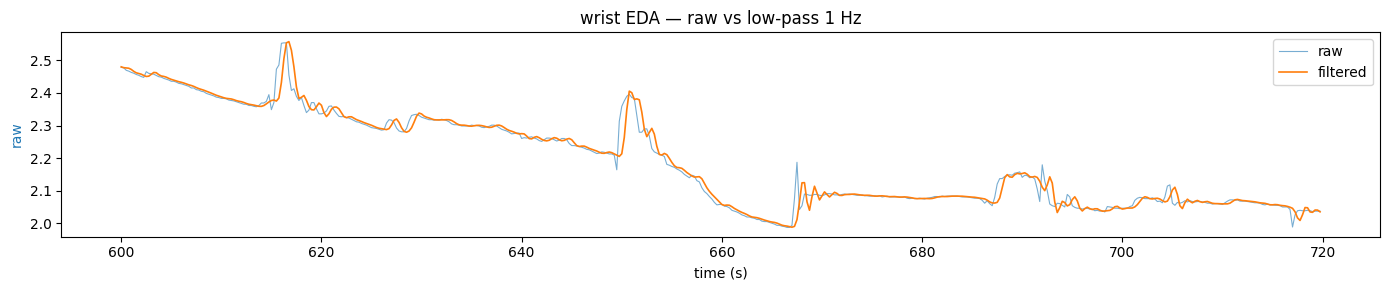

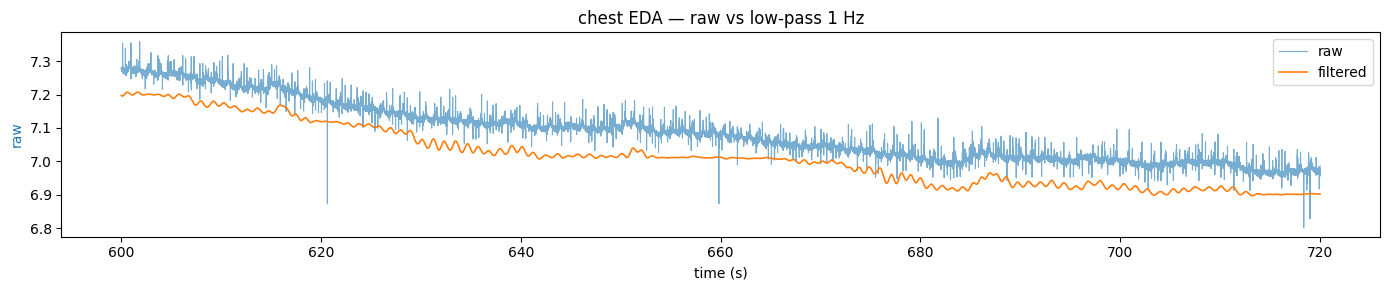

In [3]:
eda_res = {}
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['EDA']
    raw = np.asarray(data['signal'][loc]['EDA']).ravel()
    eda_res[loc] = wp.eda_decompose(raw, fs)
    compare(raw, eda_res[loc]['EDA'], fs, f'{loc} EDA — raw vs low-pass 1 Hz', dur_s=120)

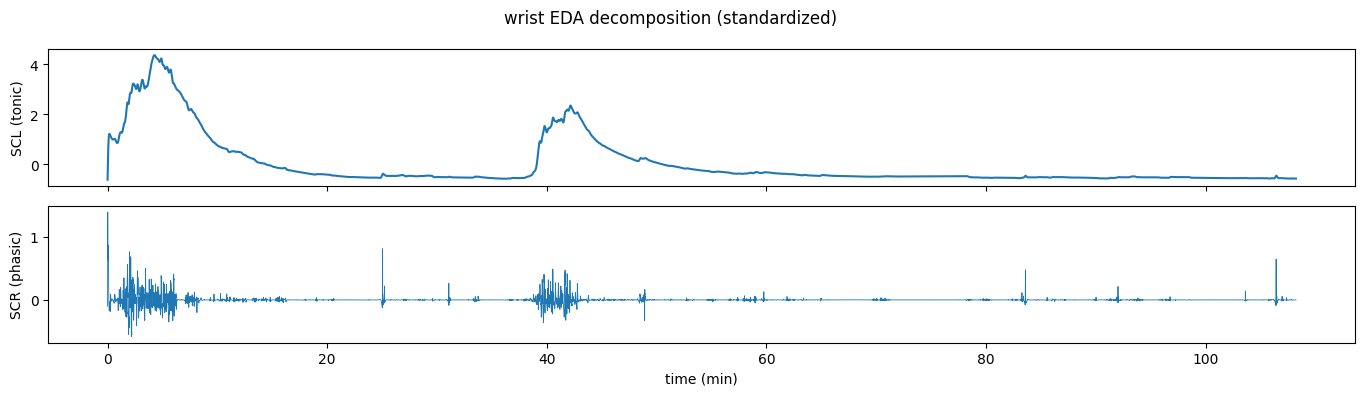

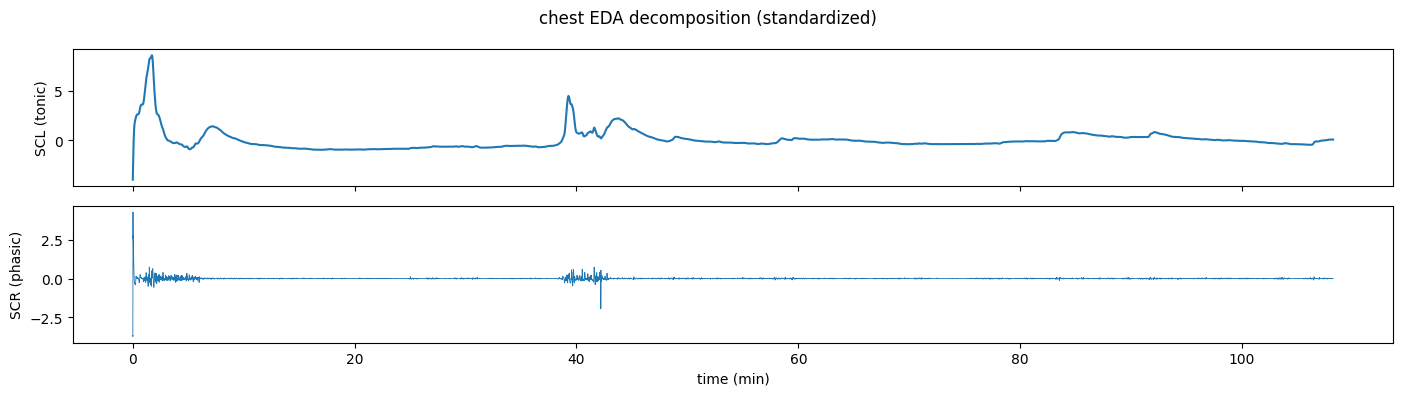

In [4]:
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['EDA']
    r = eda_res[loc]
    step = max(1, len(r['EDA_SCL']) // 20_000)
    t = np.arange(0, len(r['EDA_SCL']), step) / fs / 60
    fig, ax = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
    ax[0].plot(t, r['EDA_SCL'][::step]); ax[0].set_ylabel('SCL (tonic)')
    ax[1].plot(t, r['EDA_SCR'][::step], lw=0.6); ax[1].set_ylabel('SCR (phasic)')
    ax[1].set_xlabel('time (min)'); fig.suptitle(f'{loc} EDA decomposition (standardized)'); fig.tight_layout(); plt.show()

## 2. ACC — FIR low-pass (FIXED)

Original `_forked`:
```python
for _ in acc_df.columns:
    acc_df[_] = utils.filterSignalFIR(acc_df.values)   # 2-D array, filtered across x/y/z, fs always 32 Hz
```

Fixed version:
```python
acc_df[_] = wp.filter_signal_fir(acc_df.values, fs=actual_fs)   # axis=0, per-rate cutoff
```

> The filtered ACC should now look like a proper low-pass version of the raw signal (same amplitude scale, smoothed).

wrist: raw abs-max [128. 128. 128.]  ->  filtered abs-max [66.497 71.328 60.252]


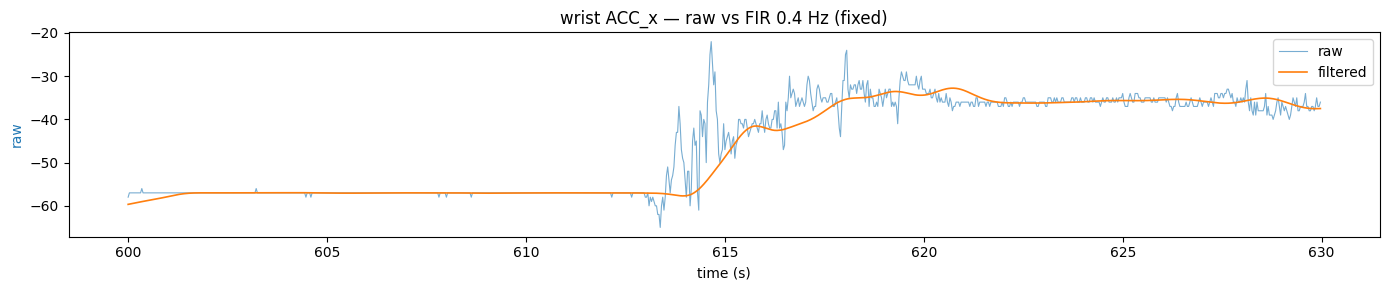

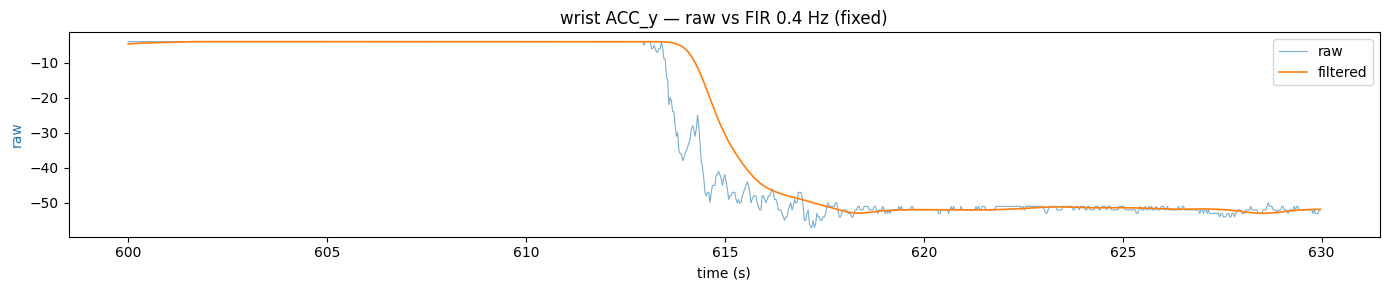

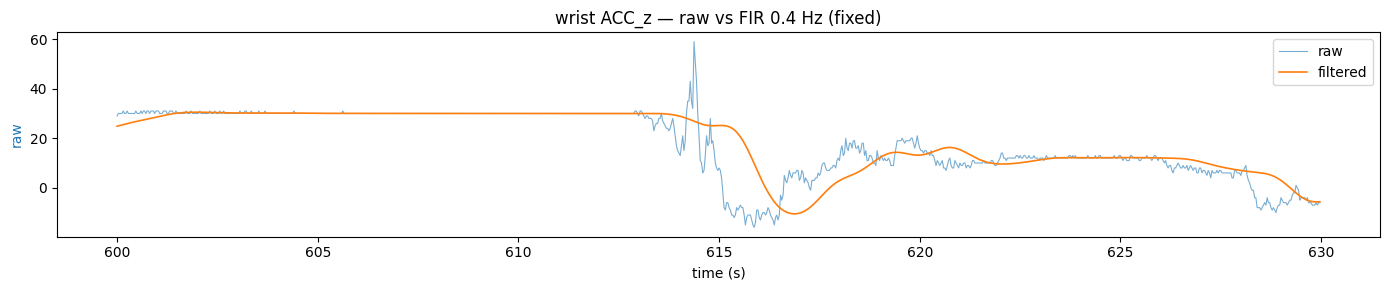

chest: raw abs-max [6.6 6.6 6.6]  ->  filtered abs-max [6.6 6.6 6.6]


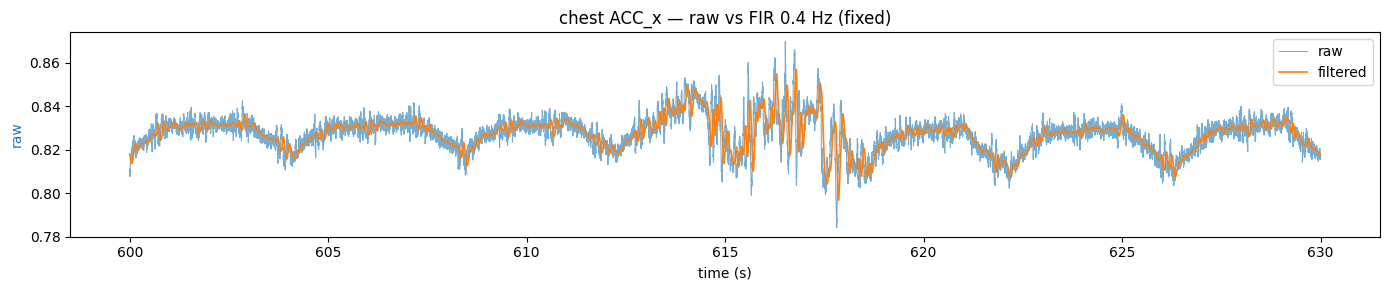

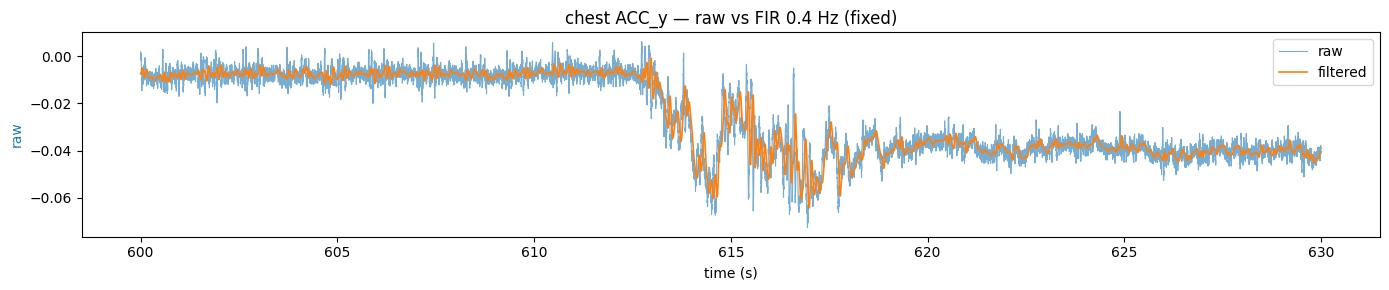

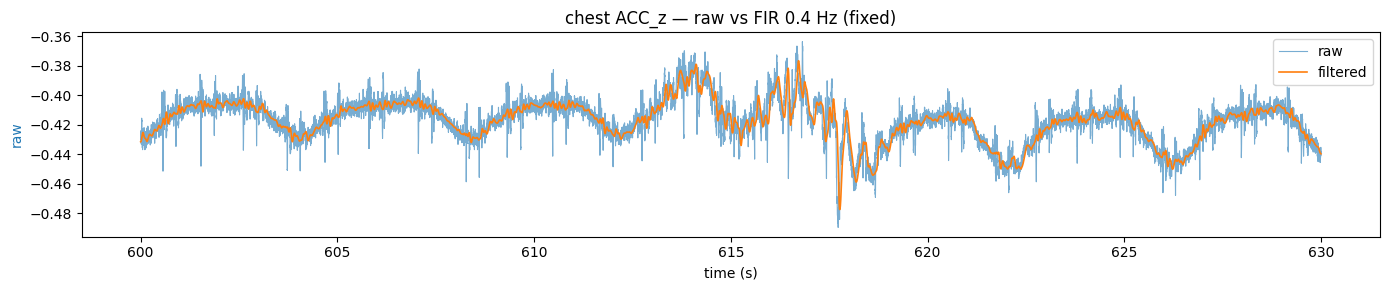

In [5]:
acc_res = {}
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['ACC']
    raw = np.asarray(data['signal'][loc]['ACC'], dtype=float)
    acc_res[loc] = wp.filter_signal_fir(raw, fs=fs)
    print(f'{loc}: raw abs-max {np.abs(raw).max(axis=0).round(3)}  ->  '
          f'filtered abs-max {np.abs(acc_res[loc]).max(axis=0).round(3)}')
    for i, ax_name in enumerate('xyz'):
        compare(raw[:, i], acc_res[loc][:, i], fs, f'{loc} ACC_{ax_name} — raw vs FIR 0.4 Hz (fixed)',
                dur_s=30, twin=False)

## 3. Passthrough signals

Same as the original — these are not filtered at the preprocessing stage.

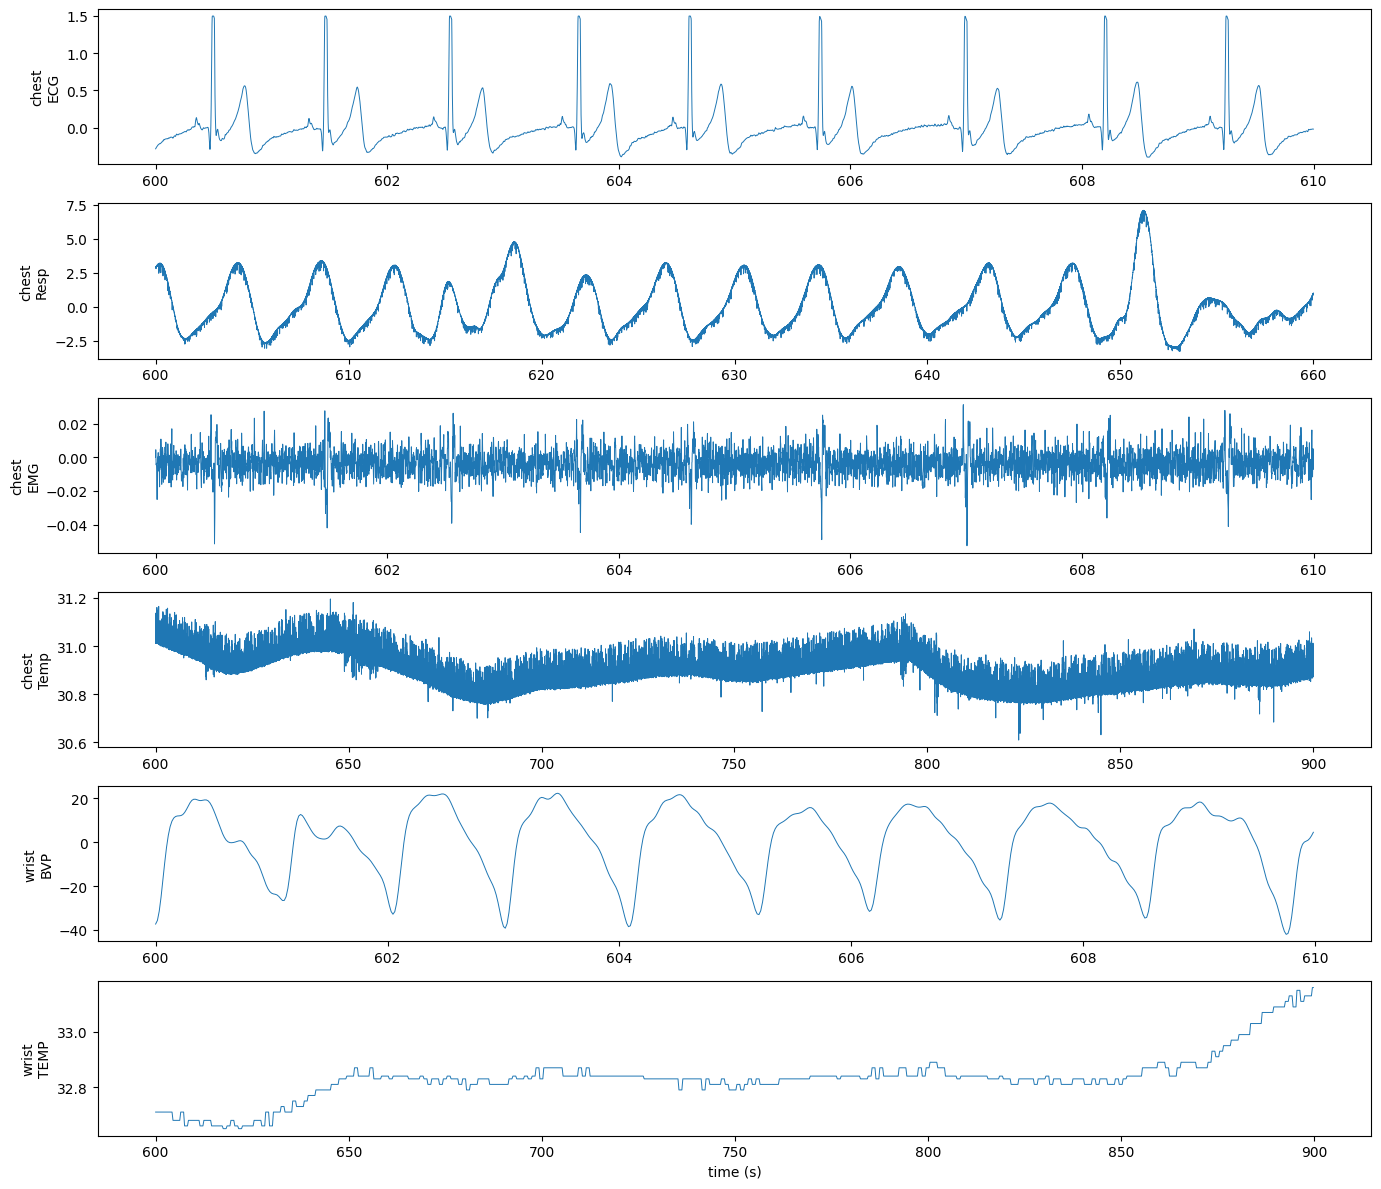

In [6]:
passthrough = [('chest', 'ECG', 10), ('chest', 'Resp', 60), ('chest', 'EMG', 10),
               ('chest', 'Temp', 300), ('wrist', 'BVP', 10), ('wrist', 'TEMP', 300)]
fig, axes = plt.subplots(len(passthrough), 1, figsize=(14, 2.0 * len(passthrough)))
for ax, (loc, name, dur) in zip(axes, passthrough):
    fs = wp.FS[loc][name]
    arr = np.asarray(data['signal'][loc][name]).ravel()
    a = 600 * fs
    ax.plot(np.arange(a, a + dur * fs) / fs, arr[a:a + dur * fs], lw=0.7)
    ax.set_ylabel(f'{loc}\n{name}')
axes[-1].set_xlabel('time (s)'); fig.tight_layout(); plt.show()

## 4. All-in-one

`wp.filter_subject` runs everything above for every sensor.

In [7]:
filtered = wp.filter_subject(data)
for loc in ('chest', 'wrist'):
    print(loc, {k: v.shape for k, v in filtered[loc].items()})

chest {'ACC': (4545100, 3), 'ECG': (4545100,), 'EMG': (4545100,), 'EDA': (4545100,), 'EDA_SCR': (4545100,), 'EDA_SCL': (4545100,), 'Temp': (4545100,), 'Resp': (4545100,)}
wrist {'ACC': (207776, 3), 'BVP': (415552,), 'EDA': (25972,), 'EDA_SCR': (25972,), 'EDA_SCL': (25972,), 'TEMP': (25972,)}


In [8]:
del data, filtered, eda_res, acc_res